augmentacion

    Probabilidades:
        15% RIR (reverberación)
        15% Add Noise SNR (3-20 dB aleatorio)
        15% Gaussian Noise
        15% Time Shift
        15% Magnitude Warping
        15% Polarity Inversion
        10% Ganancia aleatoria (0.3x a 2.0x)

In [2]:
"""
augmentation.py — Módulo de aumentación de audio
Importa esto en tu pipeline y llama a augmentar(audio_np)

Uso:
    from augmentation import cargar_rir, augmentar
    cargar_rir()  # una sola vez al inicio
    audio_aumentado = augmentar(audio_np)  # audio_np: numpy array (N,)
"""

import os
import torch
import torchaudio
import torchaudio.functional as F
import urllib.request

_rir = None

# CARGAR RIR
def cargar_rir(ruta="rir_voces.wav"):
    global _rir
    if not os.path.exists(ruta):
        print("Descargando RIR...")
        url = "https://download.pytorch.org/torchaudio/tutorial-assets/Lab41-SRI-VOiCES-rm1-impulse-mc01-stu-clo-8000hz.wav"
        urllib.request.urlretrieve(url, ruta)
        print("RIR descargado.")
    rir_raw, rir_sr = torchaudio.load(ruta)
    rir = rir_raw[:, int(rir_sr * 1.01): int(rir_sr * 1.3)]
    _rir = rir / torch.linalg.vector_norm(rir, ord=2)
    print("RIR listo.")


# FUNCIONES INDIVIDUALES

def _rir_aug(w):
    try:
        aug = F.fftconvolve(w, _rir)
        aug = aug[:, :w.shape[1]]
        m = aug.abs().max()
        return aug / m if m > 0 else aug
    except Exception:
        return w

def _add_noise_snr(w):
    snr_db = float(torch.empty(1).uniform_(3, 20).item())
    return F.add_noise(w, torch.randn_like(w), torch.tensor([snr_db]))

def _gaussian_noise(w):
    std = float(torch.empty(1).uniform_(0.002, 0.01).item())
    aug = w + torch.randn_like(w) * std
    m = aug.abs().max()
    return aug / m if m > 0 else aug

def _time_shift(w):
    sr    = 22050
    max_m = int(0.5 * sr)
    shift = torch.randint(-max_m, max_m, (1,)).item()
    return torch.roll(w, shifts=shift, dims=1)

def _magnitude_warping(w):
    N      = w.shape[1]
    puntos = (1.0 + 0.6 * torch.randn(12)).unsqueeze(0).unsqueeze(0)
    curva  = torch.nn.functional.interpolate(
        puntos, size=N, mode="linear", align_corners=True
    ).squeeze()
    return w * curva.unsqueeze(0)

def _polarity_inversion(w):
    return w * -1

def _ganancia(w):
    factor = float(torch.empty(1).uniform_(0.3, 2.0).item())
    return (w * factor).clamp(-1, 1)


def augmentar(audio_np):
    """
    Entrada:  numpy array (N,) — el audio como tú lo tengas
    Salida:   numpy array (N,) — mismo tamaño, con una aumentación aplicada


    """
    w = torch.tensor(audio_np).float().unsqueeze(0)  # (1, N)
    p = torch.rand(1).item()

    if p < 0.15:
        w = _rir_aug(w)
    elif p < 0.30:
        w = _add_noise_snr(w)
    elif p < 0.45:
        w = _gaussian_noise(w)
    elif p < 0.60:
        w = _time_shift(w)
    elif p < 0.75:
        w = _magnitude_warping(w)
    elif p < 0.90:
        w = _polarity_inversion(w)
    else:
        w = _ganancia(w)

    return w.squeeze(0).numpy()

In [30]:
cargar_rir()

import torchaudio
import torchaudio.transforms as T

waveform, sr = torchaudio.load(r"F:\UIS\2026-1\TRATAMIENTO DE SENALES DISCRETAS\PROYECTO\DATOS LIMPIOS Y A 4s\UrbanSound8K_4sec\fold1\103258-5-0-15.wav")

# Resamplear si es necesario
if sr != 22050:
    resample = T.Resample(orig_freq=sr, new_freq=22050)
    waveform = resample(waveform)

audio_np = waveform.mean(dim=0).numpy()




RIR listo.


In [34]:

import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import librosa.display
import numpy as np
from IPython.display import Audio, display


# Donde tú quieras en tu pipeline, sobre el wav crudo
audio_aumentado = augmentar(audio_np)



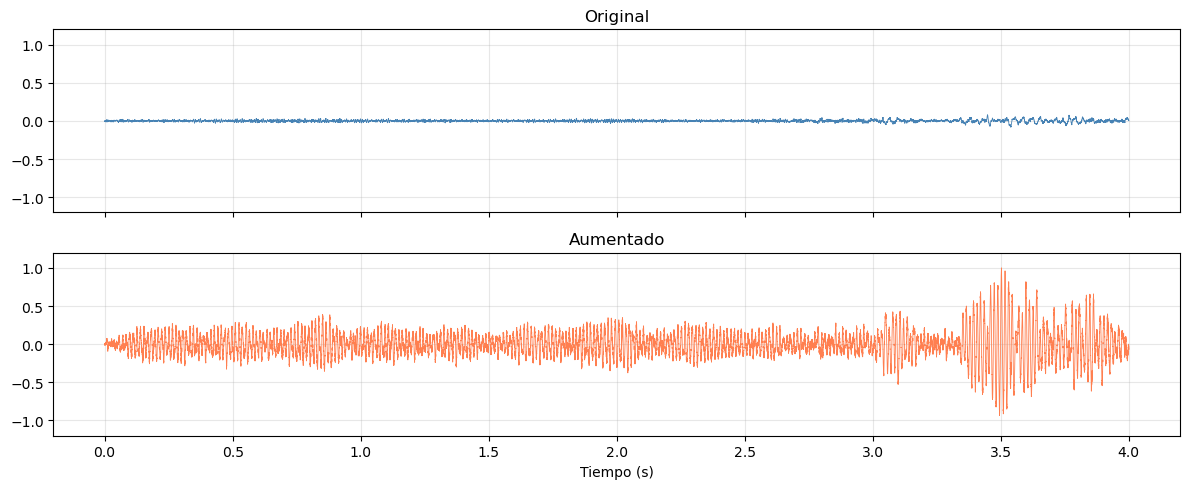

In [35]:
display(Audio(audio_aumentado, rate=22050))

display(Audio(audio_np, rate=22050))
tiempo = np.linspace(0, len(audio_np) / 22050, len(audio_np))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(tiempo, audio_np,  color='steelblue', linewidth=0.6)
ax1.set_title("Original")
ax1.set_ylim(-1.2, 1.2)
ax1.grid(True, alpha=0.3)

ax2.plot(tiempo, audio_aumentado, color='coral', linewidth=0.6)
ax2.set_title("Aumentado")
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel("Tiempo (s)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
for i in range(5):
    audio_aug = augmentar(audio_np)
    print(f"Intento {i+1}: min={audio_aug.min():.4f}  max={audio_aug.max():.4f}")

Intento 1: min=-0.2789  max=0.6587
Intento 2: min=-0.4030  max=0.3854
Intento 3: min=-0.8087  max=1.0000
Intento 4: min=-0.7362  max=0.3117
Intento 5: min=-0.6470  max=0.2989
